In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:
df = pd.read_csv('/loan_prediction_dataset.csv')
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [ ]:
df.shape

(2000, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.isnull().sum()

,0
Age,0
Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term,0
Employment_Status,0
Loan_Approved,0


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Employment_Status'],
    drop_first=True
)

df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,0,False,False
1,69,102879,781,21013,24,1,True,False
2,46,58827,779,39687,60,0,True,False
3,32,127188,364,16886,24,0,False,True
4,60,25655,307,26256,36,0,False,True


In [ ]:
print(df['Loan_Approved'].value_counts())

Loan_Approved
0    1658
1     342
Name: count, dtype: int64


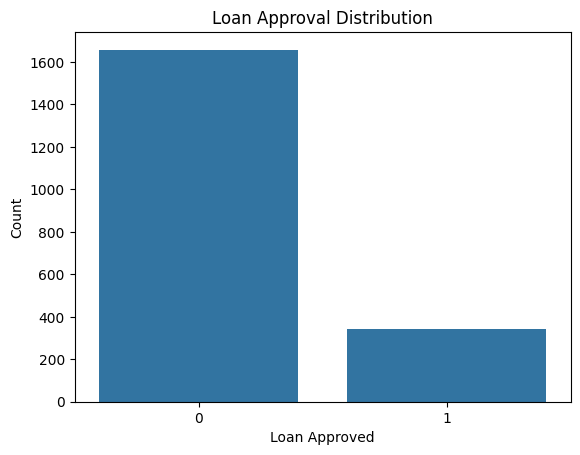

In [ ]:
sns.countplot(x='Loan_Approved', data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.show()

In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Income Lower Limit:", lower_limit)
print("Income Upper Limit:", upper_limit)

outliers = df[
    (df['Income'] < lower_limit) |
    (df['Income'] > upper_limit)
]

print("Income Outliers:", len(outliers))

Income Lower Limit: -48971.75
Income Upper Limit: 217420.25
Income Outliers: 0


In [ ]:
Q1 = df['Loan_Amount'].quantile(0.25)
Q3 = df['Loan_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Loan Amount Lower Limit:", lower_limit)
print("Loan Amount Upper Limit:", upper_limit)

outliers = df[
    (df['Loan_Amount'] < lower_limit) |
    (df['Loan_Amount'] > upper_limit)
]

print("Loan Amount Outliers:", len(outliers))

Loan Amount Lower Limit: -23313.25
Loan Amount Upper Limit: 74706.75
Loan Amount Outliers: 0


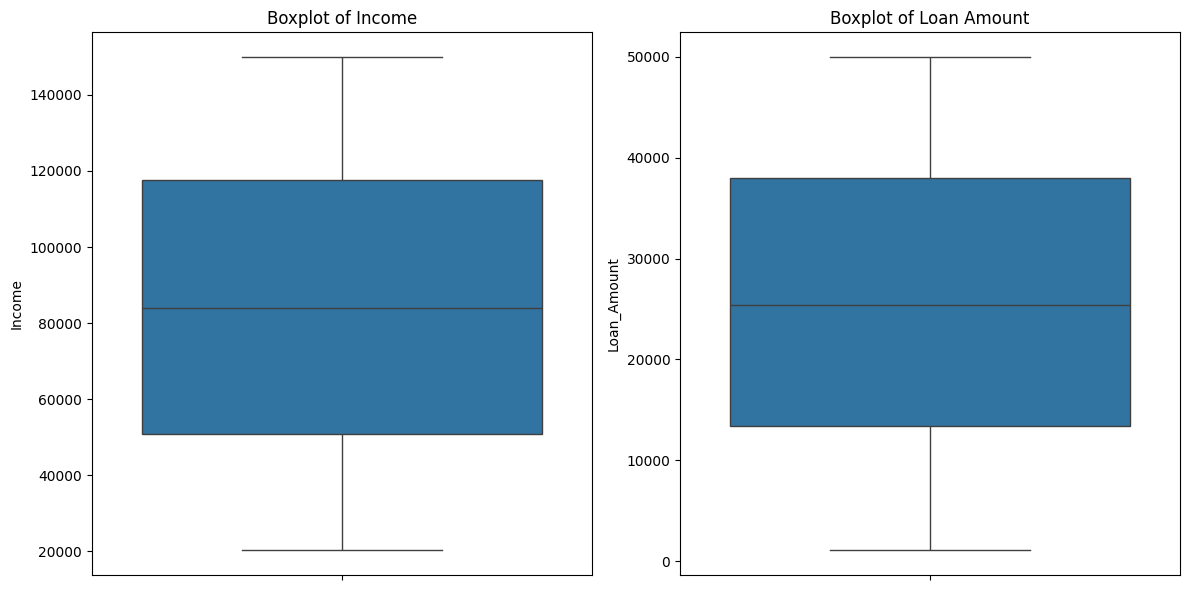

In [ ]:
# Create boxplots to visualize outliers for 'Income' and 'Loan_Amount'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=df['Income'])
plt.title('Boxplot of Income')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df['Loan_Amount'])
plt.title('Boxplot of Loan Amount')

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1600, 7)
X_test: (400, 7)
y_train: (1600,)
y_test: (400,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.928125
Testing Accuracy: 0.915


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[317  15]
 [ 19  49]]


In [ ]:
TN, FP, FN, TP = cm.ravel()

print("True Negative (TN):", TN)
print("True Positive (TP):", TP)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)

True Negative (TN): 317
True Positive (TP): 49
False Positive (FP): 15
False Negative (FN): 19


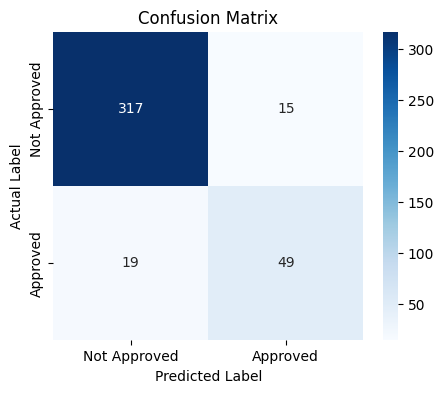

In [ ]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Approved', 'Approved'],
    yticklabels=['Not Approved', 'Approved']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
class_report = classification_report(
    y_test,
    y_pred
)

print(class_report)

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       332
           1       0.77      0.72      0.74        68

    accuracy                           0.92       400
   macro avg       0.85      0.84      0.85       400
weighted avg       0.91      0.92      0.91       400



In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("AUC Score:", auc_score)

AUC Score: 0.9660258681785967


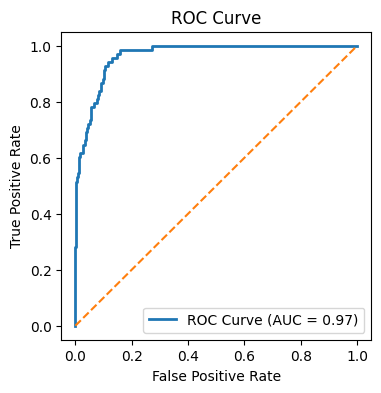

In [ ]:
plt.figure(figsize=(4,4))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label='ROC Curve (AUC = %0.2f)' % auc_score
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()